### Import Required Libraries

- `pandas` is used for data manipulation and analysis.
- `numpy` is used for numerical computations.

These libraries form the foundation for data preprocessing and analysis.

In [2]:
import pandas as pd
import numpy as np

### Load the HR Dataset

- The dataset is loaded using `pd.read_csv()`.
- `df.head(5)` displays the first five records to verify successful loading and understand the data structure.

In [3]:
df = pd.read_csv("HR-Employee-Attrition.csv")
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Check Dataset Dimensions

- `df.shape` returns the number of rows and columns.
- Helps understand dataset size and scope of analysis.

In [4]:
print(df.shape)

(1470, 35)


### Inspect Dataset Information

- `df.info()` provides:
  - column names
  - data types
  - non-null counts
- Useful for detecting data type issues and missing values.

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### Check Missing Values

- `df.isnull().sum()` identifies missing values in each column.
- Important for deciding data cleaning strategies.

In [6]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Encode Target Variable

- Converts Attrition from categorical to numeric:
  - Yes → 1
  - No → 0
- Required for machine learning models.

In [7]:
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

### Preview Updated Dataset

- Displays the dataset after encoding.
- Ensures transformation was applied correctly.

In [8]:
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Import Visualization Libraries

- `seaborn` for statistical visualizations.
- `matplotlib.pyplot` for plotting control.

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

### Overall Attrition Distribution

- Count plot shows number of employees who stayed vs left.
- Helps understand class imbalance in the dataset.

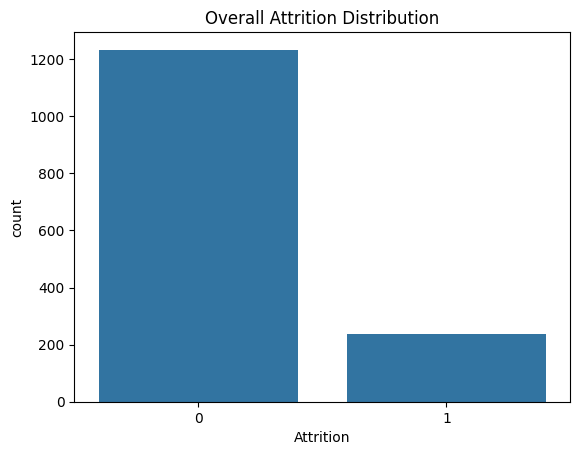

In [10]:
sns.countplot(x='Attrition', data=df)
plt.title("Overall Attrition Distribution")
plt.show()

### Attrition by Department

- Visualizes attrition across departments.
- Helps identify high-risk departments.

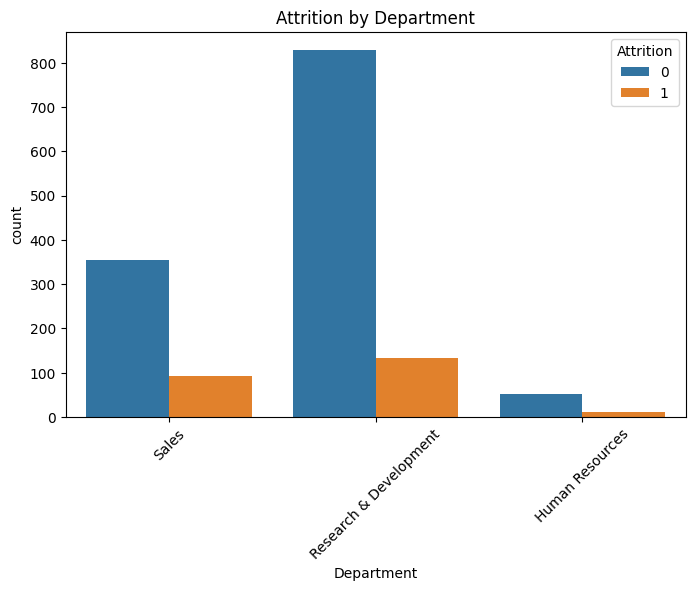

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='Department', hue='Attrition', data=df)
plt.xticks(rotation=45)
plt.title("Attrition by Department")
plt.show()

### Salary Band vs Attrition

- Monthly income is grouped into bands using `pd.cut()`.
- Count plot shows attrition pattern across salary levels.
- Helps analyze compensation impact.

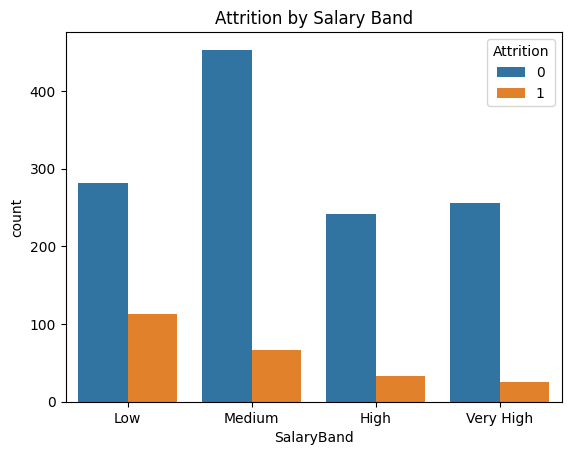

In [12]:
df['SalaryBand'] = pd.cut(df['MonthlyIncome'],
                          bins=[0,3000,6000,10000,20000],
                          labels=['Low', 'Medium', 'High', 'Very High'])
sns.countplot(x='SalaryBand', hue='Attrition', data=df)
plt.title("Attrition by Salary Band")
plt.show()

### Promotion vs Attrition

- Boxplot compares years since last promotion with attrition.
- Helps evaluate whether lack of promotion drives resignations.

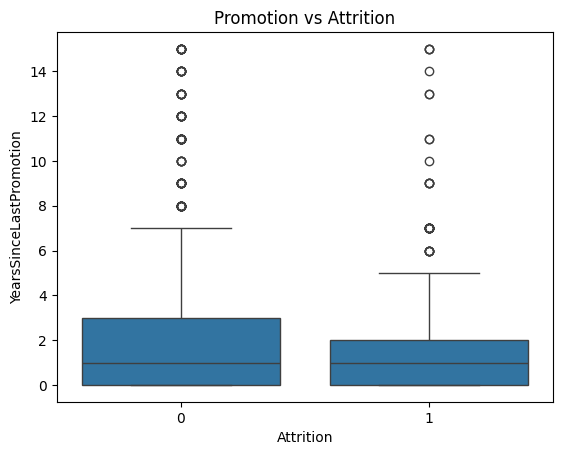

In [13]:
sns.boxplot(x='Attrition', y='YearsSinceLastPromotion', data=df)
plt.title("Promotion vs Attrition")
plt.show()

### Correlation Heatmap

- Shows relationships between numerical features.
- Helps detect strong predictors and multicollinearity.

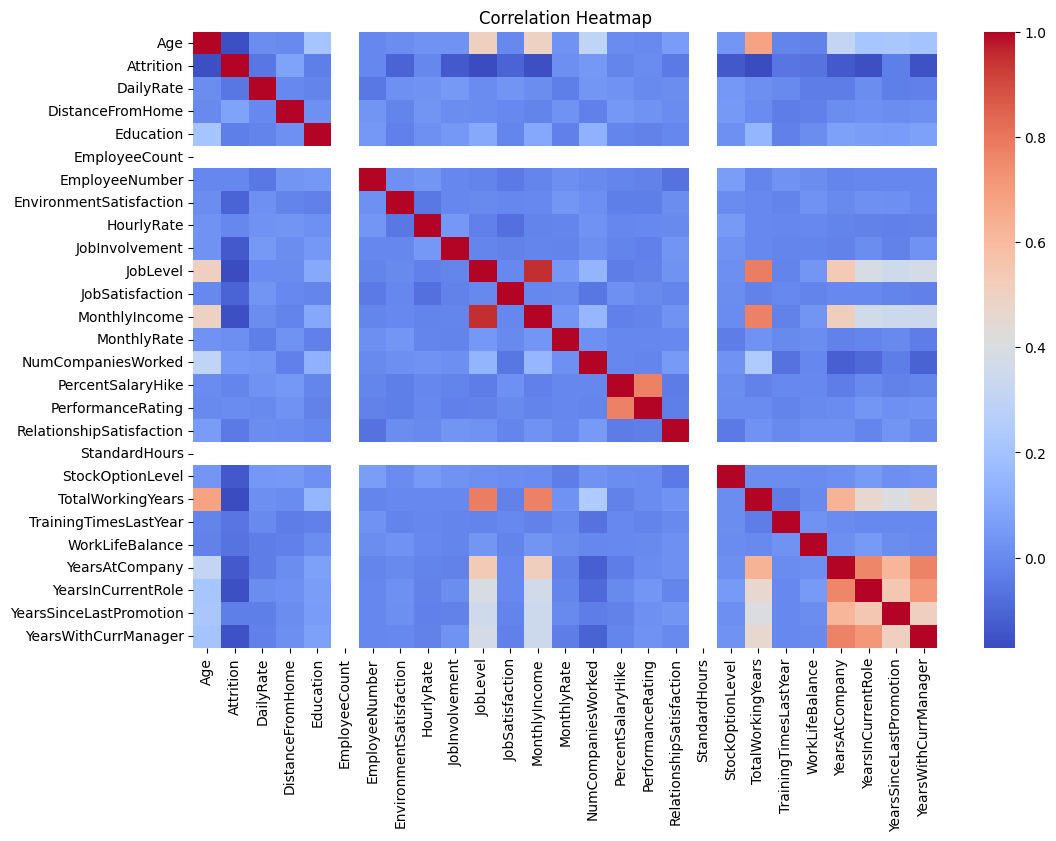

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Feature Engineering

New features created:

- **IncomePerYearAtCompany**
  - Measures salary growth relative to tenure.

- **IsRecentlyPromoted**
  - Binary flag for employees promoted within last year.

These features improve model predictive power.

In [15]:
df['IncomePerYearAtCompany'] = df['MonthlyIncome'] / (df['YearsAtCompany'] + 1)
df['IsRecentlyPromoted'] = (df['YearsSinceLastPromotion'] <= 1).astype(int)

### Prepare Data for Modeling

Steps performed:

1. Separate features (X) and target (y)
2. Apply one-hot encoding to categorical variables
3. Split data into train and test sets
4. Use stratification to preserve class distribution

This prepares data for machine learning.

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop('Attrition', axis=1)
X = pd.get_dummies(X, drop_first=True)

y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train shape:", X_train.shape)

Train shape: (1176, 52)


### Train Logistic Regression Model

- Logistic Regression is used as baseline classifier.
- `max_iter=1000` ensures convergence.
- Model is trained on training data.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

C:\Users\Yogita\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

### Evaluate Logistic Regression

Metrics computed:

- Accuracy
- Confusion Matrix
- Classification Report

These measure model performance on unseen data.

In [18]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8537414965986394
[[246   1]
 [ 42   5]]
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       247
           1       0.83      0.11      0.19        47

    accuracy                           0.85       294
   macro avg       0.84      0.55      0.55       294
weighted avg       0.85      0.85      0.80       294



### Confusion Matrix Heatmap

- Visual representation of prediction results.
- Helps identify false positives and false negatives.

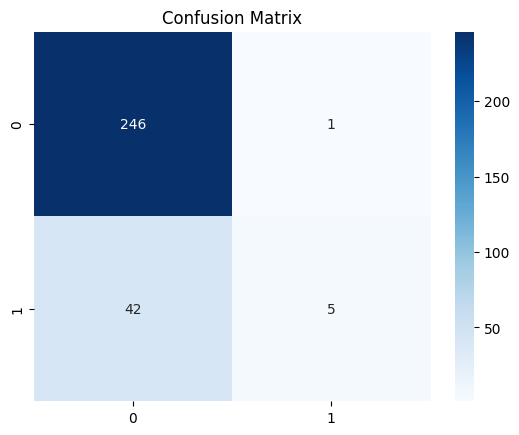

In [19]:
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

### Import Advanced ML Tools

- SMOTE for class imbalance handling
- Random Forest classifier
- ROC and evaluation metrics

These support improved modeling.

In [20]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

### Logistic Regression with Class Weights

- `class_weight='balanced'` handles class imbalance.
- Model predictions and ROC-AUC are evaluated.
- Provides improved minority detection.

In [21]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

print("LOGISTIC REGRESSION RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.6666666666666666
[[163  84]
 [ 14  33]]
              precision    recall  f1-score   support

           0       0.92      0.66      0.77       247
           1       0.28      0.70      0.40        47

    accuracy                           0.67       294
   macro avg       0.60      0.68      0.59       294
weighted avg       0.82      0.67      0.71       294

ROC-AUC: 0.7511413558446033


C:\Users\Yogita\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


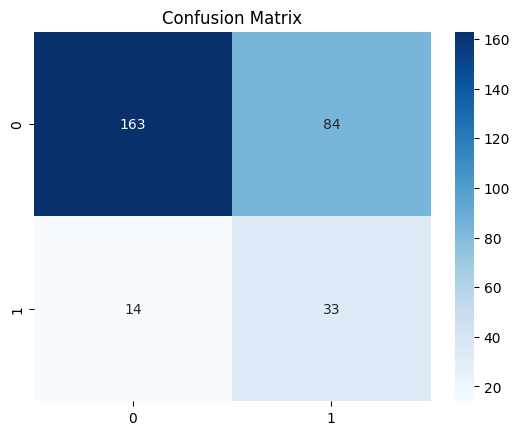

In [22]:
sns.heatmap(confusion_matrix(y_test, y_pred_log),
            annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

### Handle Class Imbalance Using SMOTE

- SMOTE generates synthetic minority samples.
- Applied only on training data.
- Balances attrition classes before modeling.

In [23]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())

Before SMOTE: Attrition
0    986
1    190
Name: count, dtype: int64
After SMOTE: Attrition
0    986
1    986
Name: count, dtype: int64


### Logistic Regression After SMOTE

- Model trained on balanced dataset.
- Performance compared with previous models.
- Typically improves recall for attrition.

LOGISTIC + SMOTE RESULTS
Accuracy: 0.8197278911564626
[[216  31]
 [ 22  25]]
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       247
           1       0.45      0.53      0.49        47

    accuracy                           0.82       294
   macro avg       0.68      0.70      0.69       294
weighted avg       0.83      0.82      0.83       294

ROC-AUC: 0.753639417693169


C:\Users\Yogita\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


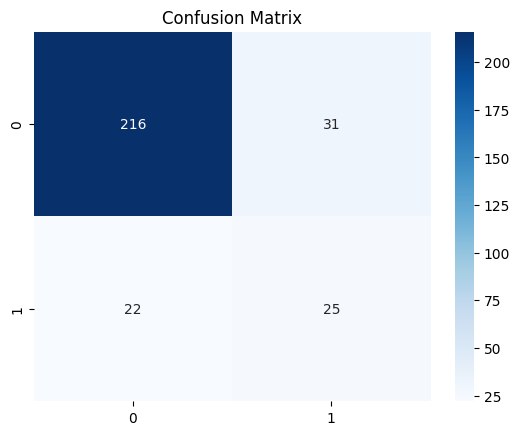

In [24]:
log_smote = LogisticRegression(max_iter=1000, random_state=42)

log_smote.fit(X_train_sm, y_train_sm)

y_pred_log_sm = log_smote.predict(X_test)
y_prob_log_sm = log_smote.predict_proba(X_test)[:,1]

print("LOGISTIC + SMOTE RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_log_sm))
print(confusion_matrix(y_test, y_pred_log_sm))
print(classification_report(y_test, y_pred_log_sm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log_sm))

sns.heatmap(confusion_matrix(y_test, y_pred_log_sm),
            annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

### Train Random Forest Classifier

- Ensemble model with 300 trees.
- Depth limited to prevent overfitting.
- Class weights handle imbalance.
- Usually best performer for tabular HR data.

RANDOM FOREST RESULTS
Accuracy: 0.8571428571428571
[[237  10]
 [ 32  15]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.60      0.32      0.42        47

    accuracy                           0.86       294
   macro avg       0.74      0.64      0.67       294
weighted avg       0.84      0.86      0.84       294

ROC-AUC: 0.8116116805926438


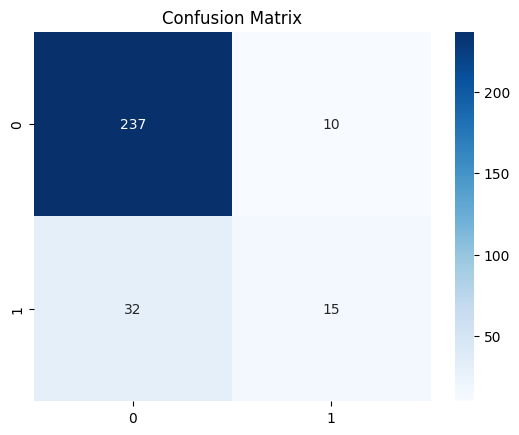

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train_sm, y_train_sm)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("RANDOM FOREST RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

### Feature Importance Extraction

To further interpret the Random Forest model, feature importance scores are extracted. Random Forest inherently measures how much each feature contributes to reducing prediction error across the ensemble of trees. A structured dataframe is created to rank features by their importance, allowing identification of the top drivers of employee attrition. This ranking supports both business insight generation and executive storytelling in the Power BI dashboard.

In [26]:
import pandas as pd

# Get feature importance
importance = rf_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

,Feature,Importance
48,OverTime_Yes,0.105904
47,MaritalStatus_Single,0.057362
18,StockOptionLevel,0.048870
11,MonthlyIncome,0.041052
6,EnvironmentSatisfaction,0.037611
10,JobSatisfaction,0.035466
9,JobLevel,0.032207
25,YearsWithCurrManager,0.032082
0,Age,0.030542
28,BusinessTravel_Travel_Frequently,0.030412


In [27]:
feature_importance_df.to_csv("C:/Users/Yogita/OneDrive/Desktop/ELEVETA/project1/feature_importance.csv", index=False)

### Generate Attrition Risk Scores and Export Final Dataset

In this step, the trained Random Forest model is used to compute the probability of attrition for each employee. These probabilities are then converted into business-friendly risk categories (High, Medium, Low) to help HR teams quickly identify employees who may require retention interventions.

Finally, the enriched dataset — including predicted probabilities and risk segmentation — is exported as a CSV file for downstream visualization and storytelling in Power BI.

**Business Value:**
- Enables proactive identification of at-risk employees  
- Supports targeted retention strategies  
- Provides a predictive layer for the Power BI dashboard  

In [28]:
df['Attrition_Probability'] = rf_model.predict_proba(X)[:,1]
def risk_bucket(p):
    if p >= 0.6:
        return "High Risk"
    elif p >= 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

df['Risk_Category'] = df['Attrition_Probability'].apply(risk_bucket)
df.to_csv("C:/Users/Yogita/OneDrive/Desktop/ELEVETA/project1/HR_Attrition_final.csv", index=False)

### Probability Threshold Tuning

- Default threshold (0.5) adjusted to 0.30.
- Improves recall for attrition class.
- Helps identify more high-risk employees.

In [29]:
# try different threshold
threshold = 0.30

y_pred_rf_tuned = (y_prob_rf >= threshold).astype(int)

print("RANDOM FOREST (TUNED THRESHOLD)")
print(confusion_matrix(y_test, y_pred_rf_tuned))
print(classification_report(y_test, y_pred_rf_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf_tuned))

RANDOM FOREST (TUNED THRESHOLD)
[[195  52]
 [ 11  36]]
              precision    recall  f1-score   support

           0       0.95      0.79      0.86       247
           1       0.41      0.77      0.53        47

    accuracy                           0.79       294
   macro avg       0.68      0.78      0.70       294
weighted avg       0.86      0.79      0.81       294

ROC-AUC: 0.7777155655095185


### ROC Curve Visualization

- Plots True Positive Rate vs False Positive Rate.
- Evaluates model discrimination ability.
- Closer to top-left indicates better model.

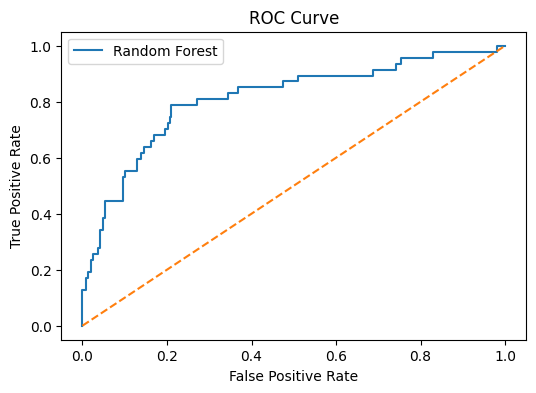

In [30]:
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label='Random Forest')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Compare Model Performance

- Creates summary table of all models.
- Compares Accuracy and ROC-AUC.
- Helps select final production model.

In [31]:
results = pd.DataFrame({
    'Model': ['Logistic Balanced', 'Logistic + SMOTE', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_log_sm),
        accuracy_score(y_test, y_pred_rf)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_log_sm),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

print(results)

               Model  Accuracy   ROC_AUC
0  Logistic Balanced  0.666667  0.751141
1   Logistic + SMOTE  0.819728  0.753639
2      Random Forest  0.857143  0.811612


### Feature Importance Analysis

- Extracts important predictors from Random Forest.
- Displays top 10 drivers of attrition.
- Useful for HR decision-making and storytelling.

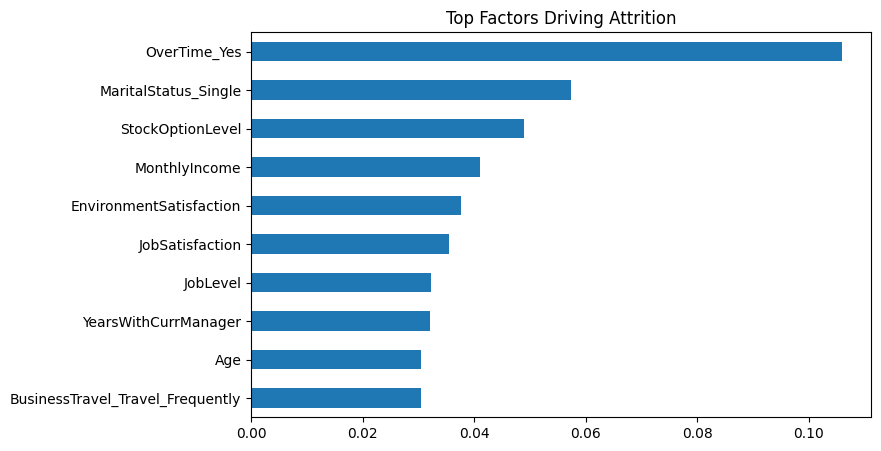

In [32]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.head(10).plot(kind='barh')
plt.title("Top Factors Driving Attrition")
plt.gca().invert_yaxis()
plt.show()

### SHAP Initialization and Feature Encoding

The SHAP library is imported to enable model interpretability and explain the contribution of each feature toward attrition prediction. The feature matrix is then transformed using one-hot encoding to convert categorical variables into a numerical format suitable for machine learning algorithms. The dataset is subsequently split into training and testing subsets using stratified sampling to preserve the original attrition distribution.

In [33]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

shap.initjs()
X_encoded = pd.get_dummies(X, drop_first=True)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

### Random Forest Model Training

A Random Forest classifier is trained using the prepared training dataset. The model leverages an ensemble of decision trees to capture complex nonlinear relationships within the HR data. With 200 estimators and a fixed random state for reproducibility, the model is optimized to provide robust attrition risk predictions for downstream analysis and SHAP-based explainability.

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

### SHAP-Based Model Interpretability

To enhance model transparency and support data-driven HR decisions, SHAP (SHapley Additive exPlanations) analysis is performed on the trained Random Forest model.

SHAP helps quantify the contribution of each feature toward predicting employee attrition risk. The analysis provides both a detailed distribution view (summary plot) and a ranked importance view (bar plot), enabling stakeholders to clearly understand the key drivers behind employee turnover.

**Business Value:**
- Improves trust in the predictive model  
- Identifies the most influential attrition factors  
- Supports targeted and explainable HR retention strategies  
- Strengthens executive storytelling in the Power BI dashboard  

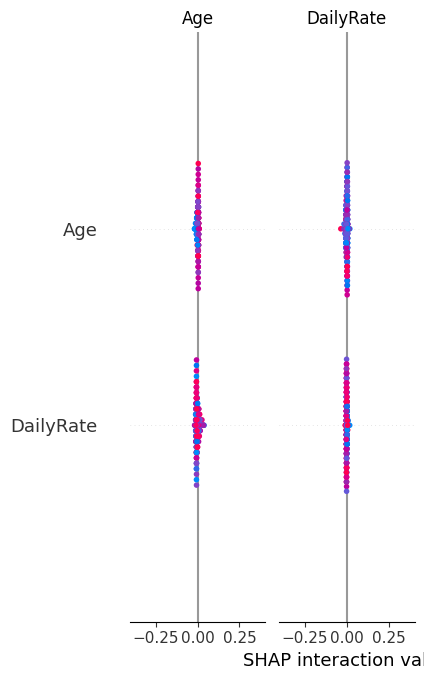

In [76]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test)   

shap.summary_plot(shap_values, X_test)